<table style="width:100%;">
  <tr>
    <td style="text-align: left; vertical-align: middle;">
      <h2>Ciência de Dados</h2>
      <p>
        Prof. Túlio Ribeiro<br>
        <br>
        Núcleo de Ciência de Dados e Inteligência Artificial (NCDIA)<br>
        <br>
        Universidade de Fortaleza
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle;">
      <img src="https://www.unifor.br/o/unifor-theme/images/unifor-logo-horizontal.svg" width="200px">
    </td>
  </tr>
</table>


## 1. Regressão Logística

A regressão logística (ou regressão logit) pode ser definida pela seguinte expressão:

\begin{equation}
\widehat{p} = h_{\boldsymbol{\theta}}(\mathbf{x}) = \sigma(\mathbf{x}^T\boldsymbol{\theta}) = \frac{1}{1+\exp(-\mathbf{x}^T\boldsymbol{\theta})},
\end{equation}

onde $\widehat{p}$ é a probabilidade estimada do modelo e $\sigma(t)$ é uma função sigmoide dada por:

\begin{equation}
    \sigma(t) = \frac{1}{1+\exp(-t)}.
\end{equation}

Geralmente, a regressão logística é usada em tarefas de classificação. Para classificação, as classes estimadas são dadas por:

\begin{equation}
\widehat{y} =
\begin{cases}
0\text{ se }\widehat{p} < 0.5\\
1\text{ se }\widehat{p} \ge 0.5
\end{cases}.
\end{equation}

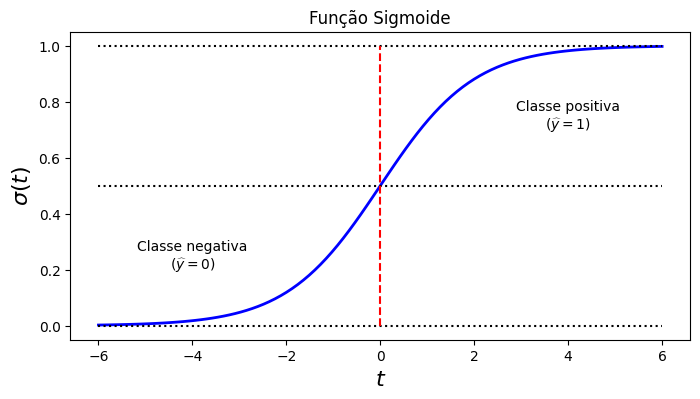

In [1]:
import numpy as np
import matplotlib.pyplot as plt

lim = 6
t = np.linspace(-lim, lim, 100)
sig = 1 / (1 + np.exp(-t))

plt.figure(figsize=(8, 4))
plt.plot(t, sig, 'b-', lw=2)

plt.plot([-lim, lim], [0, 0], 'k:')
plt.plot([-lim, lim], [0.5, 0.5], 'k:')
plt.plot([-lim, lim], [1, 1], 'k:')
plt.plot([0, 0], [0, 1], 'r--')

plt.annotate('Classe positiva\n($\\widehat{y} = 1$)', xy=(4, 0.7), ha='center')
plt.annotate('Classe negativa\n($\\widehat{y} = 0$)', xy=(-4, 0.2), ha='center')

plt.xlabel('$t$', fontsize=16)
plt.ylabel(r'$\sigma(t)$', fontsize=16)
plt.title('Função Sigmoide')
plt.show()

### 1.1 Função de Custo

Para uma dada instância $i$, podemos calcular o custo associado:

\begin{equation}
c^{(i)}(\boldsymbol{\theta}) =
\begin{cases}
- \log(\widehat{p}^{(i)})\text{, se }y^{(i)} = 1\\
- \log(1 - \widehat{p}^{(i)})\text{, se }y^{(i)} = 0
\end{cases}.
\end{equation}

Tal condição pode ser transformada na seguinte expressão:

\begin{equation}
c^{(i)}(\boldsymbol{\theta}) = - y^{(i)}\log(\widehat{p}^{(i)}) - (1 - y^{(i)})\log(1 - \widehat{p}^{(i)})
\end{equation}

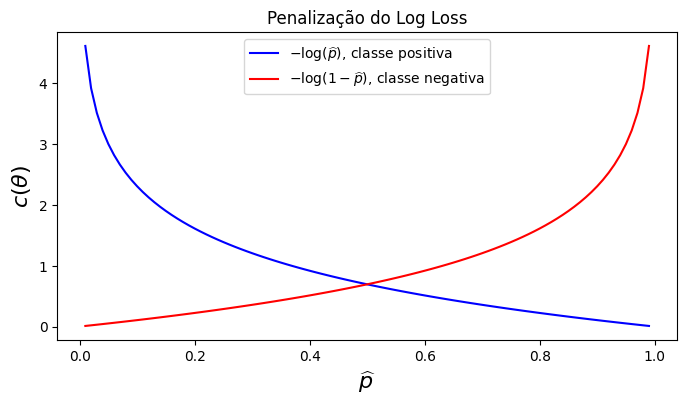

In [3]:
p = np.arange(0.01, 1, 0.01)

plt.figure(figsize=(8, 4))
plt.plot(p, -np.log(p), 'b-', label='$-\\log(\\widehat{p})$, classe positiva')
plt.plot(p, -np.log(1 - p), 'r-', label='$-\\log(1 - \\widehat{p})$, classe negativa')

plt.legend(loc='best')
plt.xlabel(r'$\widehat{p}$', fontsize=16)
plt.ylabel(r'$c(\theta)$', fontsize=16)
plt.title('Penalização do Log Loss')
plt.show()

A função de custo para a regressão logística é o log da perda (ou log loss), dada por:

\begin{equation}
J(\boldsymbol{\theta}) = \frac{1}{m} \sum_{i=1}^m c^{(i)}(\boldsymbol{\theta}) = - \frac{1}{m} \sum_{i=1}^m\left[ y^{(i)}\log(\widehat{p}^{(i)}) + (1 - y^{(i)})\log(1 - \widehat{p}^{(i)})\right].
\end{equation}

- Não existe uma expressão fechada para $J(\boldsymbol{\theta})$;
- Entretanto, ela é convexa! Logo, podemos usar um algoritmo iterativo de otimização (e.g., o Gradiente Descendente).

A derivada dessa função de custo fica:

\begin{equation}
\frac{\partial}{\partial \theta_j}J(\boldsymbol{\theta}) = \frac{1}{m} \sum_{i=1}^m\left[ \widehat{p}^{(i)} - y^{(i)}\right] x_j^{(i)}.
\end{equation}

### 1.2 Fronteira de decisão

In [4]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris(as_frame=True)
df = iris.frame
display(df.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
df['target'].value_counts()

,count
target,
0,50
1,50
2,50


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


#### 1.2.1 Para uma característica

In [7]:
from sklearn.model_selection import train_test_split

# Isolando a característica e binarizando o alvo
X = df[['petal width (cm)']].to_numpy()
y = (df['target'] == 2).astype(np.int64) # 1 se Virginica, 0 se Não-Virginica

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [8]:
from sklearn.linear_model import LogisticRegression

# Treinamento do modelo Scikit-Learn
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(random_state=42)

In [10]:
log_reg.predict([[1.5]])

array([0])

In [16]:
log_reg.predict_proba([[1.5]])

array([[0.6403484, 0.3596516]])

In [17]:
# Geração de dados sintéticos para visualização da curva
X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
p = log_reg.predict_proba(X_new)

In [ ]:
p[:10]

array([[0.99820801, 0.00179199],
       [0.99818732, 0.00181268],
       [0.99816638, 0.00183362],
       [0.99814521, 0.00185479],
       [0.99812379, 0.00187621],
       [0.99810213, 0.00189787],
       [0.99808021, 0.00191979],
       [0.99805804, 0.00194196],
       [0.99803562, 0.00196438],
       [0.99801294, 0.00198706]])

In [18]:
log_reg.predict(X_new)[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
p[0]

array([0.99820801, 0.00179199])

In [19]:
# Identificação da fronteira onde a probabilidade cruza 0.5
decision_boundary = X_new[p[:, 1] >= 0.5][0, 0]
print(decision_boundary)

1.6516516516516517


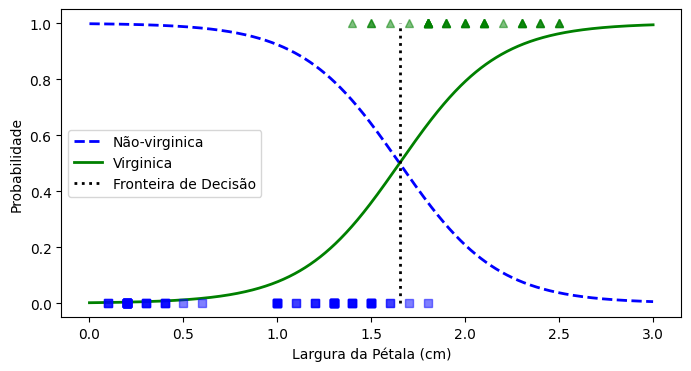

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(X_new, p[:, 0], 'b--', lw=2, label='Não-virginica')
plt.plot(X_new, p[:, 1], 'g-', lw=2, label='Virginica')
plt.plot([decision_boundary, decision_boundary], [0, 1], 'k:', lw=2, label='Fronteira de Decisão')

# Plot dos dados reais de treinamento
plt.plot(X_train[y_train == 0], y_train[y_train == 0], 'bs', alpha=0.5)
plt.plot(X_train[y_train == 1], y_train[y_train == 1], 'g^', alpha=0.5)

plt.xlabel('Largura da Pétala (cm)')
plt.ylabel('Probabilidade')
plt.legend(loc='center left')
plt.show()

In [22]:
y_hat = log_reg.predict([[1.5],
                         [1.7]])
y_hat

array([0, 1])

In [23]:
y_hat_prob = log_reg.predict_proba([[1.5],
                                    [1.7]])
y_hat_prob

array([[0.6403484 , 0.3596516 ],
       [0.45283447, 0.54716553]])

#### 1.2.2 Para duas características

A fronteira de decisão em duas dimensões é dada por $\widehat{p} = 0.5$, o que implica $t = 0$.$$\theta_0 + \theta_1 x_1 + \theta_2 x_2 = 0 \Rightarrow x_2 = -(\theta_0 + \theta_1 x_1) / \theta_2$$

In [24]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Seleção de duas características
X = df[['petal length (cm)', 'petal width (cm)']].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [25]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

print(log_reg.intercept_, log_reg.coef_)

[-15.81793954] [[2.56143021 2.00397536]]


In [26]:
# Criação de malha para visualização da probabilidade (Heatmap)
x1, x2 = np.meshgrid(np.linspace(1, 7, 500), np.linspace(0, 3, 200))
X_new = np.column_stack((x1.ravel(), x2.ravel()))
p = log_reg.predict_proba(X_new)

In [27]:
p = log_reg.predict_proba(X_new)
print(p.shape)

(100000, 2)


In [28]:
p[:10]

array([[9.99998251e-01, 1.74892180e-06],
       [9.99998196e-01, 1.80362439e-06],
       [9.99998140e-01, 1.86003795e-06],
       [9.99998082e-01, 1.91821601e-06],
       [9.99998022e-01, 1.97821376e-06],
       [9.99997960e-01, 2.04008810e-06],
       [9.99997896e-01, 2.10389773e-06],
       [9.99997830e-01, 2.16970320e-06],
       [9.99997762e-01, 2.23756691e-06],
       [9.99997692e-01, 2.30755325e-06]])

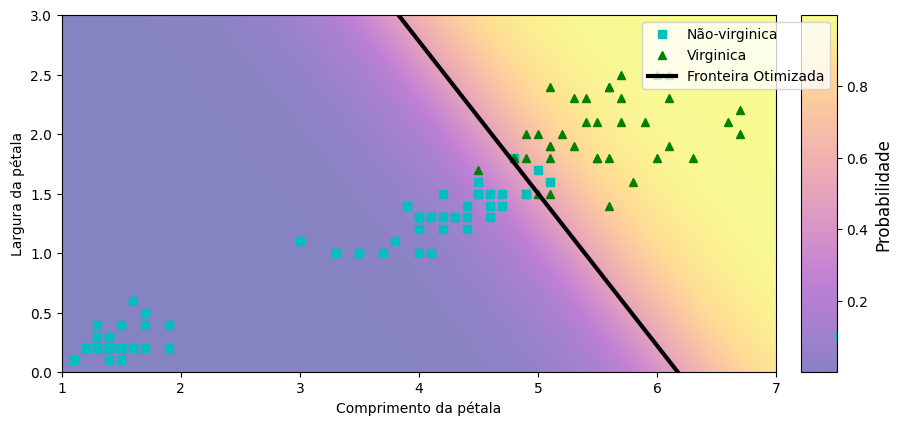

In [30]:
# Cálculo vetorial da fronteira de decisão
petal_lenghts = np.array([3.8, 6.2])
petal_widths = -(log_reg.intercept_[0] + log_reg.coef_[0, 0] * petal_lenghts) / log_reg.coef_[0, 1]

plt.figure(figsize=(10, 5))
plt.plot(X_train[y_train == 0, 0], X_train[y_train == 0, 1], 'cs', label='Não-virginica')
plt.plot(X_train[y_train == 1, 0], X_train[y_train == 1, 1], 'g^', label='Virginica')
plt.plot(petal_lenghts, petal_widths, 'k-', lw=3, label='Fronteira Otimizada')

plt.xlabel('Comprimento da pétala')
plt.ylabel('Largura da pétala')
plt.axis([1, 7, 0, 3])

ax = plt.gca()
surface = p[:, 1].reshape((200, 500))
limites_teta = [1, 7, 0, 3]

image = ax.imshow(surface, extent=limites_teta, cmap=plt.cm.plasma, origin='lower', alpha=0.5)
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.25)
cbar = plt.colorbar(image, cax=cax)
cbar.set_label(r'Probabilidade', size=12)

# Adicione o parâmetro 'label' em cada plot
plt.plot(X_train[y_train == 0, 0], X_train[y_train == 0, 1], 'cs', label='Não-virginica')
plt.plot(X_train[y_train == 1, 0], X_train[y_train == 1, 1], 'g^', label='Virginica')
plt.plot(petal_lenghts, petal_widths, 'k-', lw=3, label='Fronteira Otimizada')

# A legenda agora processará os rótulos informados acima
plt.legend(loc='upper right')
plt.show()

## 2. Abordagens Interativas e Dinâmicas de Aprendizado

As seções a seguir demonstram a otimização matemática do modelo, a visualização multidimensional da probabilidade e as limitações das fronteiras lineares.

### 2.1 Exploração Manual dos Pesos

Ajuste os parâmetros $\theta$ para compreender a influência do viés e dos coeficientes na inclinação e posição da fronteira linear.

In [31]:
import ipywidgets as widgets
from IPython.display import display
import numpy as np

def plot_fronteira_manual(theta0, theta1, theta2):
    plt.figure(figsize=(8, 5))
    plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='cyan', marker='s', label='Não-Virginica')
    plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='green', marker='^', label='Virginica')

    x_plot = np.linspace(X_train[:, 0].min()-1, X_train[:, 0].max()+1, 100)

    # Prevenção de erro matemático (divisão por zero)
    if theta2 != 0:
        y_plot = -(theta0 + theta1 * x_plot) / theta2
        plt.plot(x_plot, y_plot, 'k-', lw=2, label='Fronteira Manual')

    # Cálculo do Log Loss
    z = theta0 + theta1 * X_train[:, 0] + theta2 * X_train[:, 1]
    p_hat = 1 / (1 + np.exp(-z))
    p_hat = np.clip(p_hat, 1e-15, 1 - 1e-15)
    custo = -np.mean(y_train * np.log(p_hat) + (1 - y_train) * np.log(1 - p_hat))

    plt.xlim(X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5)
    plt.ylim(X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5)
    plt.title(f"Equação: {theta0} + ({theta1})*x1 + ({theta2})*x2 = 0\nCusto Atual (Log Loss): {custo:.4f}")
    plt.xlabel('Comprimento da Pétala')
    plt.ylabel('Largura da Pétala')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# 1. Criação manual dos controles deslizantes
slider_theta0 = widgets.FloatSlider(value=-15, min=-30, max=30, step=0.5, description='θ0 (Viés):')
slider_theta1 = widgets.FloatSlider(value=3, min=-10, max=10, step=0.5, description='θ1 (Comp):')
slider_theta2 = widgets.FloatSlider(value=3, min=-10, max=10, step=0.5, description='θ2 (Larg):')

# 2. Vinculação silenciosa dos controles à função (evita o print da docstring)
saida_grafico = widgets.interactive_output(plot_fronteira_manual, {
    'theta0': slider_theta0,
    'theta1': slider_theta1,
    'theta2': slider_theta2
})

# 3. Agrupamento visual dos controles e exibição final
interface_controles = widgets.VBox([slider_theta0, slider_theta1, slider_theta2])
display(interface_controles, saida_grafico)

Output()

### 2.2 Animação do Treinamento (Gradiente Descendente)

Acompanhamento iterativo da convergência da fronteira de decisão utilizando o algoritmo de Gradiente Descendente Estocástico (SGD).

In [32]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
from sklearn.linear_model import SGDClassifier
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# 1. Cálculo Prévio dos Pesos das Classes
classes_alvo = np.unique(y_train)
pesos = compute_class_weight('balanced', classes=classes_alvo, y=y_train)

# Criação do dicionário mapeando a classe ao seu respectivo peso calculado
dicionario_pesos = {classes_alvo[i]: pesos[i] for i in range(len(classes_alvo))}

In [33]:
dicionario_pesos

{np.int64(0): np.float64(0.7567567567567568),
 np.int64(1): np.float64(1.4736842105263157)}

In [34]:
# 2. Configuração dos modelos iterativos
modelo_padrao = SGDClassifier(loss='log_loss', learning_rate='constant', eta0=0.05, random_state=42)

# O modelo balanceado agora recebe o dicionário estático pré-calculado
modelo_balanceado = SGDClassifier(loss='log_loss', learning_rate='constant', eta0=0.05, class_weight=dicionario_pesos, random_state=42)

epocas = 30

# 3. Configuração estática da Figura e Eixos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Evolução do Gradiente Descendente (partial_fit)", fontsize=16)

def configurar_eixo(ax, titulo):
    ax.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], c='cyan', marker='s', label='Não-Virginica')
    ax.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], c='green', marker='^', label='Virginica')
    ax.set_xlim(X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5)
    ax.set_ylim(X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5)
    ax.set_title(titulo)
    ax.set_xlabel('Comprimento da Pétala')
    ax.set_ylabel('Largura da Pétala')
    ax.legend(loc='lower left')
    ax.grid(True, linestyle='--', alpha=0.6)

configurar_eixo(ax1, "Sem Balanceamento")
configurar_eixo(ax2, "Com Balanceamento Pré-Calculado")

linha_padrao, = ax1.plot([], [], 'k-', lw=2)
linha_balanceada, = ax2.plot([], [], 'r--', lw=2)

x_plot = np.array([X_train[:, 0].min() - 1, X_train[:, 0].max() + 1])

# 4. O "Motor" da Animação
def animar(frame):
    modelo_padrao.partial_fit(X_train, y_train, classes=classes_alvo)
    modelo_balanceado.partial_fit(X_train, y_train, classes=classes_alvo)

    if modelo_padrao.coef_[0][1] != 0:
        y_plot1 = -(modelo_padrao.intercept_[0] + modelo_padrao.coef_[0][0] * x_plot) / modelo_padrao.coef_[0][1]
        linha_padrao.set_data(x_plot, y_plot1)

    if modelo_balanceado.coef_[0][1] != 0:
        y_plot2 = -(modelo_balanceado.intercept_[0] + modelo_balanceado.coef_[0][0] * x_plot) / modelo_balanceado.coef_[0][1]
        linha_balanceada.set_data(x_plot, y_plot2)

    return linha_padrao, linha_balanceada

anim = animation.FuncAnimation(fig, animar, frames=epocas, interval=300, blit=True)

plt.close()

# Renderização do widget no Jupyter
HTML(anim.to_jshtml())

Output hidden; open in https://colab.research.google.com to view.

### 2.3 Visualização 3D da Superfície Sigmoide

Representação tridimensional da projeção das características no plano de probabilidade gerado pela função logística.

In [35]:
import plotly.graph_objects as go

# Malha de dados extrapolando os limites de treinamento
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
x_grid, y_grid = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
X_mesh = np.c_[x_grid.ravel(), y_grid.ravel()]

# Probabilidades calculadas pelo modelo otimizado (scikit-learn original)
Z = log_reg.predict_proba(X_mesh)[:, 1].reshape(x_grid.shape)

fig = go.Figure()

# Plot da superfície contínua
fig.add_trace(go.Surface(x=x_grid, y=y_grid, z=Z, colorscale='Viridis', opacity=0.8, name='Superfície Sigmoide'))

# Pontos reais mapeados no espaço 3D nas respectivas âncoras de probabilidade (0 e 1)
fig.add_trace(go.Scatter3d(x=X_train[y_train==0, 0], y=X_train[y_train==0, 1], z=np.zeros(sum(y_train==0)),
                           mode='markers', marker=dict(color='cyan', symbol='square', size=5), name='Não-Virginica'))

fig.add_trace(go.Scatter3d(x=X_train[y_train==1, 0], y=X_train[y_train==1, 1], z=np.ones(sum(y_train==1)),
                           mode='markers', marker=dict(color='green', symbol='circle', size=5), name='Virginica'))

fig.update_layout(title='Topologia de Probabilidade da Regressão Logística',
                  scene=dict(xaxis_title='Comprimento da Pétala',
                             yaxis_title='Largura da Pétala',
                             zaxis_title='Probabilidade Estimada'),
                  margin=dict(l=0, r=0, b=0, t=40))
fig.show()

### 2.4 Limitações do Modelo: Topologias Não-Lineares

A Regressão Logística traça estritamente retas (ou hiperplanos). A aplicação deste modelo em dados com separabilidade não-linear resulta em subajuste (underfitting).

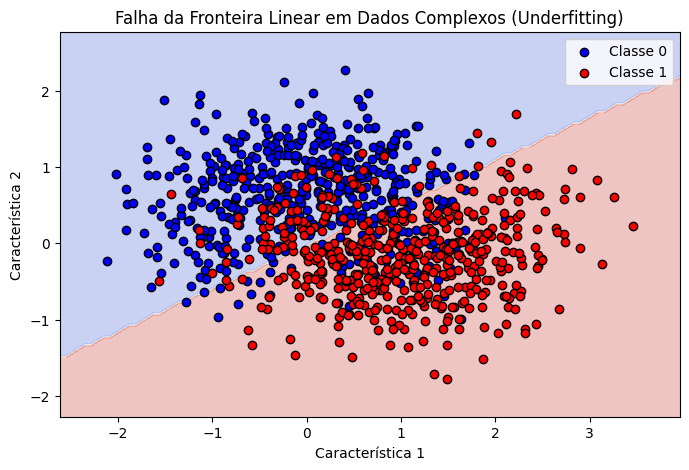

In [54]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Geração de dados sintéticos não-lineares
X_moons, y_moons = make_moons(n_samples=1000, noise=0.5, random_state=42)

# 2. Divisão dos dados em treino e teste para avaliação adequada
X_train_moons, X_test_moons, y_train_moons, y_test_moons = train_test_split(
    X_moons, y_moons, test_size=0.3, random_state=42
)

# Treinamento do modelo linear nos dados não-lineares
log_reg_moons = LogisticRegression(random_state=42)
log_reg_moons.fit(X_train_moons, y_train_moons)

# Criação da malha de decisão
x1_m, x2_m = np.meshgrid(np.linspace(X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5, 100),
                         np.linspace(X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5, 100))
X_new_m = np.c_[x1_m.ravel(), x2_m.ravel()]
y_pred_m = log_reg_moons.predict(X_new_m).reshape(x1_m.shape)

plt.figure(figsize=(8, 5))
plt.contourf(x1_m, x2_m, y_pred_m, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_moons[y_moons==0, 0], X_moons[y_moons==0, 1], color='blue', edgecolors='k', label='Classe 0')
plt.scatter(X_moons[y_moons==1, 0], X_moons[y_moons==1, 1], color='red', edgecolors='k', label='Classe 1')

plt.title("Falha da Fronteira Linear em Dados Complexos (Underfitting)")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.legend()
plt.show()

Relatório de Classificação para o Modelo Normal (make_moons):
              precision    recall  f1-score   support

           0       0.84      0.79      0.81       156
           1       0.78      0.83      0.81       144

    accuracy                           0.81       300
   macro avg       0.81      0.81      0.81       300
weighted avg       0.81      0.81      0.81       300



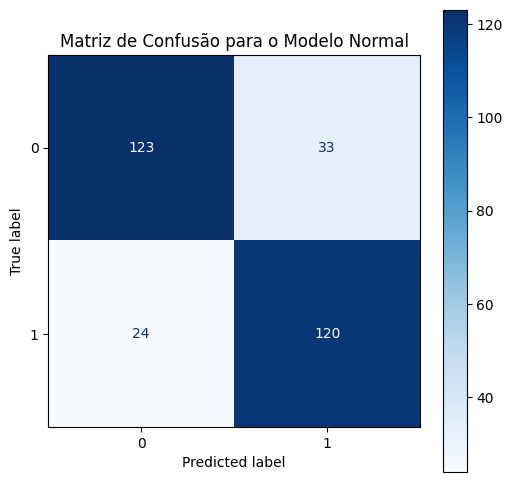

In [55]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# 4. Realizar previsões no conjunto de teste
y_pred_moons = log_reg_moons.predict(X_test_moons)

# 5. Exibir o Relatório de Classificação
print("Relatório de Classificação para o Modelo Normal (make_moons):")
print(classification_report(y_test_moons, y_pred_moons))

# 6. Plotar a Matriz de Confusão
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(log_reg_moons, X_test_moons, y_test_moons, cmap=plt.cm.Blues, ax=ax)
ax.set_title("Matriz de Confusão para o Modelo Normal")
plt.show()

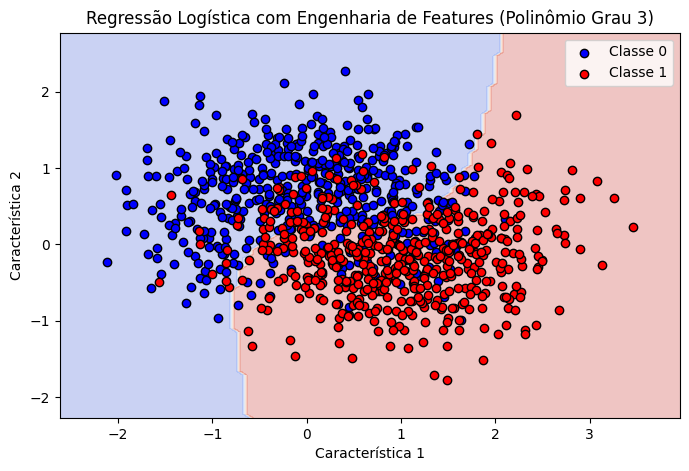

In [60]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import numpy as np

# 2. Construção da Pipeline (Transformação Polinomial -> Regressão Logística)
# degree=3 cria características elevadas até o cubo e suas interações
modelo_polinomial = Pipeline([
    ("poly_features", PolynomialFeatures(degree=3, include_bias=False)),
    ("log_reg", LogisticRegression(random_state=42))
])

# Treinamento do modelo
modelo_polinomial.fit(X_train_moons, y_train_moons)

# 3. Malha para plotagem da fronteira de decisão curva
x_min, x_max = X_moons[:, 0].min() - 0.5, X_moons[:, 0].max() + 0.5
y_min, y_max = X_moons[:, 1].min() - 0.5, X_moons[:, 1].max() + 0.5
x1_m, x2_m = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

X_new_m = np.c_[x1_m.ravel(), x2_m.ravel()]

# A Pipeline aplica a transformação polinomial automaticamente antes de prever
y_pred_m = modelo_polinomial.predict(X_new_m).reshape(x1_m.shape)

# 4. Visualização
plt.figure(figsize=(8, 5))
plt.contourf(x1_m, x2_m, y_pred_m, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(X_moons[y_moons==0, 0], X_moons[y_moons==0, 1], color='blue', edgecolors='k', label='Classe 0')
plt.scatter(X_moons[y_moons==1, 0], X_moons[y_moons==1, 1], color='red', edgecolors='k', label='Classe 1')

plt.title("Regressão Logística com Engenharia de Features (Polinômio Grau 3)")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.legend()
plt.show()

Relatório de Classificação para o Modelo Polinomial (make_moons):
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       156
           1       0.81      0.83      0.82       144

    accuracy                           0.83       300
   macro avg       0.83      0.83      0.83       300
weighted avg       0.83      0.83      0.83       300



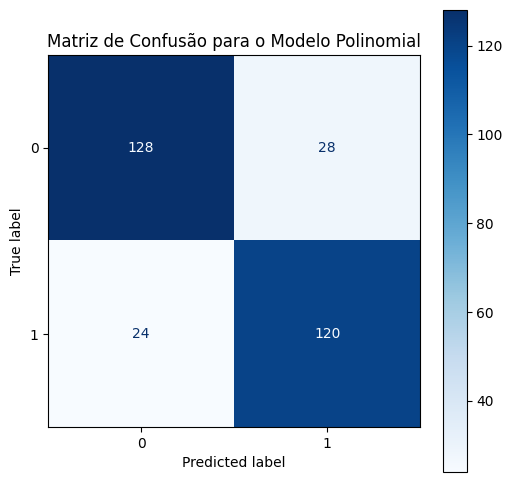

In [61]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# 4. Realizar previsões no conjunto de teste
y_pred_moons = modelo_polinomial.predict(X_test_moons)

# 5. Exibir o Relatório de Classificação
print("Relatório de Classificação para o Modelo Polinomial (make_moons):")
print(classification_report(y_test_moons, y_pred_moons))

# 6. Plotar a Matriz de Confusão
fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(modelo_polinomial, X_test_moons, y_test_moons, cmap=plt.cm.Blues, ax=ax)
ax.set_title("Matriz de Confusão para o Modelo Polinomial")
plt.show()